# SARS-CoV-2 Transmission Clustering — Pre-Model EDA

In [135]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from utils import data as ld
from utils import style as st

In [2]:
df_raw = ld.load_analysis_columns([], all_cols=True).to_pandas()
print(f"Unique sequences : {df_raw['sequence_id'].nunique():,}")
print(f"Resolutions      : {sorted(df_raw['resolution'].unique())}")
print(f"Windows          : {df_raw['window_idx'].nunique()}")

Unique sequences : 324,194
Resolutions      : [np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(0.7), np.float64(0.8)]
Windows          : 134


In [4]:
test_reason_map = {
    # symptomatic_citizen
    "symptomatic-citizen": "symptomatic_citizen",
    "I have coronavirus symptoms": "symptomatic_citizen",
    "I live~ work or study in a lockdown area with a coronavirus outbreak": "symptomatic_citizen",

    # symptomatic_essential_worker
    "symptomatic-essential-worker": "symptomatic_essential_worker",
    "Im an essential worker": "symptomatic_essential_worker",
    "scotland-wales-keyworker": "symptomatic_essential_worker",
    "wales-keyworker": "symptomatic_essential_worker",

    # contact_tracing
    "test-for-contact-tracing": "contact_tracing",
    "test-for-contact-tracing-app": "contact_tracing",
    "test-for-contact-self-referral": "contact_tracing",
    "for-symptomatic-household-member": "contact_tracing",
    "Ive been in contact with a person who has tested positive for coronavirus and Ive been asked to take a test by a contact tracer (Northern Ireland and Scotland)": "contact_tracing",
    "Ive been in contact with a person who has tested positive for coronavirus and have since developed symptoms": "contact_tracing",

    # confirmatory
    "confirmatory-positive-test": "confirmatory",
    "confirmatory-other-reason": "confirmatory",
    "confirmatory-test-unclear": "confirmatory",
    "confirmatory-test-borders": "confirmatory",
    "told-to-order-repeat-test": "confirmatory",

    # isolation_scheme
    "self-isolation-support-grant": "isolation_scheme",
    "isolation-testing-home": "isolation_scheme",
    "isolation-testing-facility": "isolation_scheme",

    # clinical
    "gp-healthcare-request": "clinical",
    "antiviral-order": "clinical",
    "dental-patient-testing": "clinical",
    "I have been told to have a test before I go into hospital~ for example~ for surgery": "clinical",

    # surveillance_research
    "zoe-symptom-study": "surveillance_research",
    "contact-testing-study": "surveillance_research",
    "events-research-programme": "surveillance_research",
    "serial-testing": "surveillance_research",
    "ntrg-member": "surveillance_research",

    # local_outbreak
    "local-council-request": "local_outbreak",
    "attended-outbreak-venue": "local_outbreak",
    "community-testing": "local_outbreak",
    "scotland-university": "local_outbreak",
    "wales-university": "local_outbreak",

    # travel
    "green-traveller": "travel",

    # other
    "other": "other",
    "Other": "other",
    "none": "other",
    "do-not-know": "other",
    "general-cta-referral": "other",
    "personal-assistant": "other",
    "Im a visiting professional": "other",
    "asymptomatic-home-order": "other",
}

df_raw["test_reason_category"] = df_raw["test_reason"].map(test_reason_map)
df_raw["test_reason_category"] = df_raw["test_reason_category"].fillna("unknown")

# Sanity check — anything not mapped?
unmapped = df_raw.loc[df_raw["test_reason"].notna() & df_raw["test_reason_category"].isna(), "test_reason"].unique()
print("Unmapped values:", unmapped)

Unmapped values: <ArrowStringArray>
[]
Length: 0, dtype: str


In [124]:
wn_cols = [
    c for c in df_raw.columns
    if c.startswith("wn") or c.startswith("win")
]
seq_cols = [c for c in df_raw.columns
            if c not in wn_cols + ["sequence_id", "resolution"]
            ]

agg_spec = {
    "ever_clustered":("cluster_size", lambda x: int((x > 1).any())),
    "n_windows": ("window_idx", "nunique"),
    "window_idx_min": ("window_idx", "min"),
    "wn_mid_date_min": ("wn_mid_date", "min"),
    "wn_prop_sequenced_mean": ("wn_prop_sequenced", "mean"),
    "wn_positive_tests_mean": ("wn_positive_tests", "mean"),
    **{col: (col, "first") for col in seq_cols},
}

seq_res = (
    df_raw
    .groupby(["sequence_id", "resolution"], sort=False)
    .agg(**agg_spec)
    .reset_index()
)
seq_res["ever_clustered"] = seq_res["ever_clustered"].astype(int)

## 1. Leiden resolution parameter
_Column_: `resolution`

_Rationale_: Higher resolutions produce smaller clusters by definition, sharply reducing the probability that a sequence lands in a cluster of size >1. Its effect is non‑linear; treat it as a factor or a smooth term.

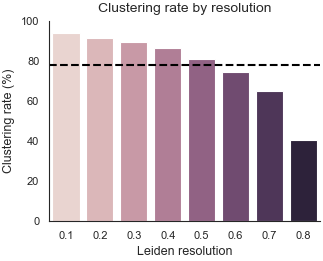

In [35]:
rate_res = (
    seq_res.groupby("resolution")["ever_clustered"]
    .agg(n_clustered="sum", n_total="count")
    .assign(pct=lambda d: 100 * d["n_clustered"] / d["n_total"])
    .reset_index()
)

fig, ax = st.new_figure("single", context="notebook")

sns.barplot(
    data=rate_res,
    x="resolution",
    y="pct",
    hue="resolution",
    ax=ax, legend=False
)
ax.axhline(rate_res["pct"].mean(), color="black", ls="--", label="Overall")
ax.set_xlabel("Leiden resolution")
ax.set_ylabel("Clustering rate (%)")
ax.set_title("Clustering rate by resolution")
ax.set_ylim(0, 100);

In [126]:
wd = seq_res.loc[seq_res["resolution"] == ld.PRIMARY_RESOLUTION].copy()
print(f"Working dataset (resolution = {ld.PRIMARY_RESOLUTION}): {len(wd):,} sequences")
print(f"Overall clustering rate: {wd['ever_clustered'].mean():.3f}")

Working dataset (resolution = 0.3): 324,194 sequences
Overall clustering rate: 0.893


2. ## Lineage and variant identity
_Columns_: `pango_lineage`, `clade`, `who_voc`

_Rationale_: Different SARS‑CoV‑2 lineages have wildly different reproductive numbers, generation intervals, and superspreading potential.

In [38]:
print(f"Variant counts (resolution = {ld.PRIMARY_RESOLUTION}):\n"
      f"{wd['pango_lineage'].nunique():,} distinct lineages\n"
      f"{wd['clade'].nunique():,} distinct clades\n"
      f"{wd['who_voc'].nunique():,} distinct WHO VOC categories\n")

Variant counts (resolution = 0.3):
862 distinct lineages
31 distinct clades
10 distinct WHO VOC categories



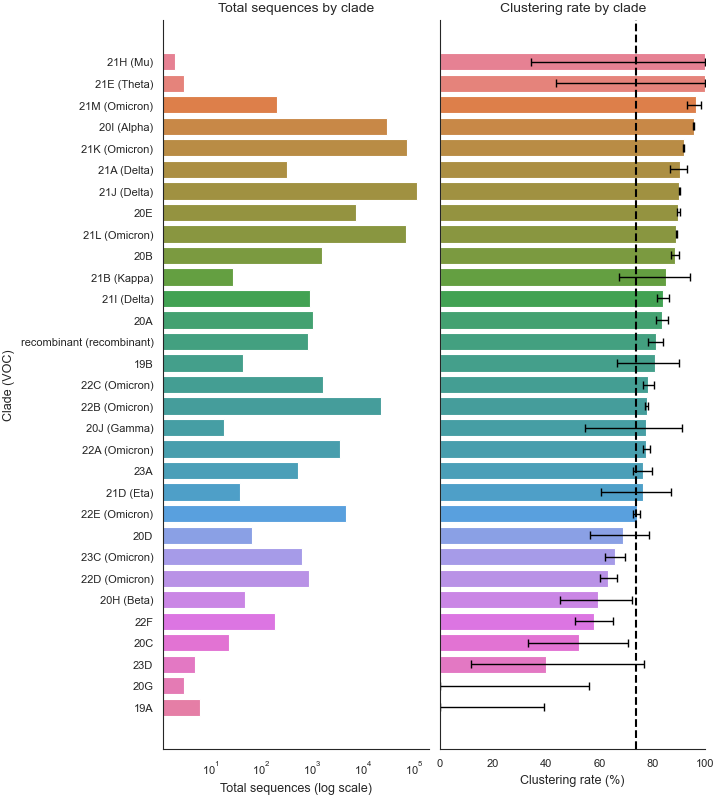

In [81]:
from statsmodels.stats.proportion import proportion_confint

clade_rates = (
    wd.groupby("clade")
    .agg(
        n_clustered=("ever_clustered", "sum"),
        n_total=("ever_clustered", "count"),
        who_voc=("who_voc", "first"),
    )
    .assign(pct=lambda d: 100 * d["n_clustered"] / d["n_total"])
    .reset_index()
    .sort_values("pct", ascending=False)
)

clade = clade_rates["clade"].astype("string")
who_voc = clade_rates["who_voc"].astype("string")

clade_rates["who_clade"] = clade.where(
    who_voc.isna(),
    clade + " (" + who_voc + ")",
)

ci = proportion_confint(
    count=clade_rates["n_clustered"],
    nobs=clade_rates["n_total"],
    alpha=0.05,
    method="wilson",
)

clade_rates["pct_low"] = 100 * ci[0]
clade_rates["pct_high"] = 100 * ci[1]

clade_rates = clade_rates.sort_values("pct", ascending=False)


fig, axes = st.new_figure(
    "double", height_in=8, sharey=True, ncols=2,
    layout="constrained", context="notebook"
)
ax_a, ax_b = axes

sns.barplot(
    data=clade_rates,
    x="n_total",
    y="who_clade",
    hue="who_clade",
    ax=ax_a, legend=False
)
ax_a.set_xlabel("Total sequences (log scale)")
ax_a.set_ylabel("Clade (VOC)")
ax_a.set_xscale("log")
ax_a.set_title("Total sequences by clade")

sns.barplot(
    data=clade_rates,
    x="pct",
    y="who_clade",
    hue="who_clade",
    ax=ax_b, legend=False
)

ax_b.errorbar(
    x=clade_rates["pct"],
    y=clade_rates["who_clade"],
    xerr=[
        clade_rates["pct"] - clade_rates["pct_low"],
        clade_rates["pct_high"] - clade_rates["pct"],
    ],
    fmt="none",
    ecolor="black",
    elinewidth=1,
    capsize=3,
)
ax_b.axvline(
    clade_rates["pct"].mean(),
    color="black", ls="--", label="Average"
)
ax_b.set_xlabel("Clustering rate (%)")
ax_b.set_title("Clustering rate by clade")
ax_b.set_xlim(0, 100);

## 3. Individual vaccination status and timing
_Columns_: `is_vaccinated`, `vacc_dose_number`, `days_since_vaccination`, `vacc_booster`, `vacc_product_name`

_Rationale_: Vaccination reduces both the risk of infection and, if infected, the intensity/duration of viral shedding, thereby lowering the chance of causing onward transmission and being part of a large cluster. The timing matters: recent vaccination (short `days_since_vaccination`) is more protective, and booster doses provide stronger protection during Omicron eras. Use `days_since_vaccination` as a continuous variable (with a sentinel value for unvaccinated) and `vacc_booster` as a binary marker.

In [106]:
vacc_cols =[
    "is_vaccinated", "vacc_dose_number", "days_since_vaccination",
]
display(wd[vacc_cols].describe(include="all"))

,is_vaccinated,vacc_dose_number,days_since_vaccination
count,324194.000000,324194.000000,214590.000000
mean,0.661918,0.911923,125.836484
std,0.473057,0.772725,86.969955
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,62.000000
50%,1.000000,1.000000,114.000000
75%,1.000000,1.000000,170.000000
max,1.000000,4.000000,715.000000


In [123]:
print(wd[vacc_cols].isna().sum())

is_vaccinated                  0
vacc_dose_number               0
days_since_vaccination    109604
dtype: int64


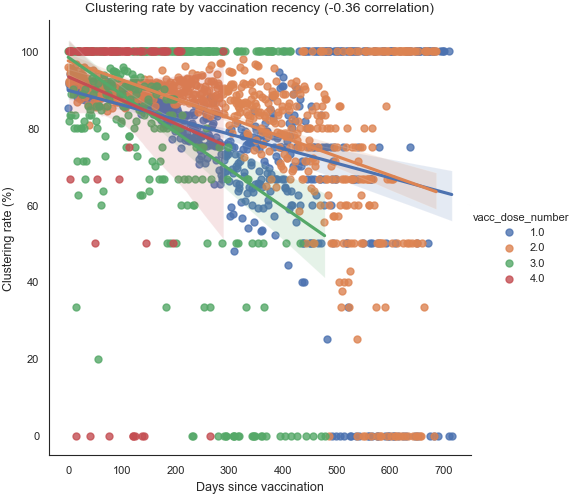

In [168]:
vacc_daily_rates = (
    wd.groupby(["days_since_vaccination", "vacc_dose_number"]).agg(
        n_total=("ever_clustered", "count"),
        n_clustered=("ever_clustered", "sum"),
    ).assign(pct=lambda d: 100 * d["n_clustered"] / d["n_total"])
    .reset_index()
)

sns.lmplot(
    data=vacc_daily_rates,
    x="days_since_vaccination",
    y="pct",
    hue="vacc_dose_number",
)
plt.xlabel("Days since vaccination")
plt.ylabel("Clustering rate (%)")
plt.title(
    f"Clustering rate by vaccination recency "
    f"({np.corrcoef(vacc_daily_rates['days_since_vaccination'],
                    vacc_daily_rates['pct'])[0, 1]:.2f} correlation)");

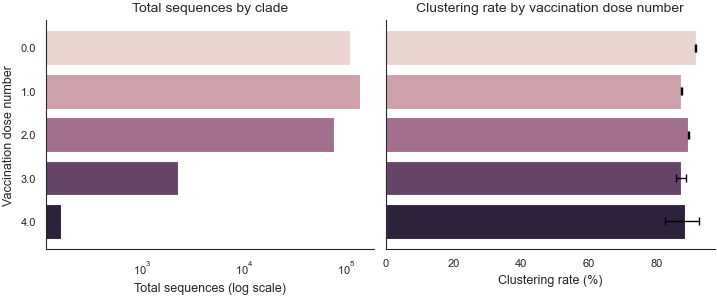

In [163]:
vacc_dose_rates = (
    wd.groupby("vacc_dose_number").agg(
        n_total=("ever_clustered", "count"),
        n_clustered=("ever_clustered", "sum"),
    ).assign(pct=lambda d: 100 * d["n_clustered"] / d["n_total"])
    .reset_index()
)

ci = proportion_confint(
    count=vacc_dose_rates["n_clustered"],
    nobs=vacc_dose_rates["n_total"],
    alpha=0.05,
    method="wilson",
)

vacc_dose_rates["pct_low"] = 100 * ci[0]
vacc_dose_rates["pct_high"] = 100 * ci[1]
vacc_dose_rates = vacc_dose_rates.sort_values("pct", ascending=False)

fig, axes = st.new_figure(
    "double", height_in=3, ncols=2, sharey=True,
    layout="constrained", context="notebook"
)
ax_a, ax_b = axes

sns.barplot(
    data=vacc_dose_rates,
    x="n_total",
    y="vacc_dose_number",
    hue="vacc_dose_number",
    ax=ax_a,
    orient="h",
    legend=False
)
ax_a.set_ylabel("Vaccination dose number")
ax_a.set_xlabel("Total sequences (log scale)")
ax_a.set_xscale("log")
ax_a.set_title("Total sequences by clade")

sns.barplot(
    data=vacc_dose_rates,
    x="pct",
    y="vacc_dose_number",
    hue="vacc_dose_number",
    ax=ax_b,
    orient="h",
    legend=False
)

ax_b.errorbar(
    x=vacc_dose_rates["pct"],
    y=vacc_dose_rates["vacc_dose_number"],
    xerr=[
        vacc_dose_rates["pct"] - vacc_dose_rates["pct_low"],
        vacc_dose_rates["pct_high"] - vacc_dose_rates["pct"],
    ],
    fmt="none",
    ecolor="black",
    elinewidth=1,
    capsize=3,
)
ax_b.set_xlabel("Clustering rate (%)")
ax_b.set_title("Clustering rate by vaccination dose number");

## 4. Area‑level deprivation and urbanicity
_Columns_: `dz_simd_quintile` or `dz_simd_decile`, `dz_urban_rural_class`, `dz_population_density`

`Rationale`: More deprived and more densely populated urban areas consistently experienced larger and more sustained transmission clusters. SIMD quintile/decile captures the socioeconomic gradient (household crowding, occupational exposure, inability to isolate), while urban‑rural class and density capture contact network structure.

## 5. Individual test context
_Columns_: `test_reason`, `test_type`, `is_reinfection`

Rationale: Test settings reflect different transmission chains. Hospital‑onset clusters can be large but are structurally different; care‑home clusters often involve highly vulnerable, closed populations. Reinfection status (`is_reinfection`) is a marker of waning immunity and higher‑risk behaviour. PCR vs. antigen type may influence sequence availability but is less biologically relevant.

## 6. Patient age and sex
_Columns_: `age_midpoint` or `age_band`, `is_female` or `sex`

Rationale: Age is a U‑shaped risk factor – young adults (high social mixing) and very elderly (care‑home clusters) are more often found in clusters. Sex modifies social mixing patterns and care‑home residency (female predominant). Use `age_midpoint` with a quadratic term or via age bands to capture non‑linearity.

## 7. Local epidemic intensity at the time of sampling
_Columns_: `dz_7d_test_positivity`, `dz_cum_incidence_per_capita`, `dz_test_positivity` (daily)

_Rationale_: When the sequence’s neighbourhood is experiencing high transmission, any positive case has a higher chance of being part of an actively expanding cluster. The 7‑day rolling test positivity is a robust, real‑time indicator of transmission intensity that accounts for testing volume fluctuations.

## 8. DZ‑level vaccination coverage and sequencing intensity (for bias control)
_Columns_: `dz_cum_prop_vaccinated`, `dz_cum_prop_sequenced`

_Rationale_: High cumulative vaccination coverage in a datazone dampens cluster growth. Equally important, dz_cum_prop_sequenced controls for ascertainment bias: if only a tiny fraction of local cases are sequenced, true clusters will be artificially fragmented and you will underestimate clustering probability; this variable can capture that surveillance artifact.